# Multiple Linear Regression — Startup Profit Prediction

This notebook builds a **Multiple Linear Regression** model to predict startup profitability based on spending in R&D, Administration, and Marketing.

I followed a structured, modular EDA pipeline:

| Phase | Description |
|-------|-------------|
| 1 | Import Libraries |
| 2 | Load Dataset |
| 3 | Shape & Structure |
| 4 | Data Types |
| 5 | Missing Values |
| 6 | Duplicate Check |
| 7 | Descriptive Statistics |
| 8 | Target Distribution |
| 9 | Feature Distributions |
| 10 | Scatter Plots (Features vs Target) |
| 11 | Categorical Analysis |
| 12 | Correlation Matrix |
| 13 | Pairplot |
| 14 | One-Hot Encoding |
| 15 | Feature–Target Split |
| 16 | Train–Test Split |
| 17 | Model Training |
| 18 | Predictions |
| 19 | Evaluation Metrics |
| 20 | Actual vs Predicted Plot |
| 21 | Residual Analysis |
| 22 | Feature Importance |
| 23 | Conclusion |

---
## 1 · Import Libraries

We import only what we need — data manipulation, visualization, and modelling.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2 · Load Dataset

Read the CSV file into a DataFrame.

In [4]:
df = pd.read_csv('50_startups_dataset.csv')
print(f'Dataset loaded — {df.shape[0]} rows, {df.shape[1]} columns.')

Dataset loaded — 50 rows, 5 columns.


---
## 3 · Shape & Structure

### 3.1 — First 5 Rows

In [5]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,Pakistan,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Istanbul,191050.39
3,144372.41,118671.85,383199.62,Pakistan,182901.99
4,142107.34,91391.77,366168.42,Istanbul,166187.94


### 3.2 — Last 5 Rows

In [6]:
df.tail()

,R&D Spend,Administration,Marketing Spend,State,Profit
45,1000.23,124153.04,1903.93,Pakistan,64926.08
46,1315.46,115816.21,297114.46,Istanbul,49490.75
47,0.00,135426.92,0.00,California,42559.73
48,542.05,51743.15,0.00,Pakistan,35673.41
49,0.00,116983.80,45173.06,California,14681.40


### 3.3 — Shape

In [7]:
print(f'Rows   : {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows   : 50
Columns: 5


### 3.4 — Column Names

In [8]:
print(df.columns.tolist())

['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit']


---
## 4 · Data Types

Verify which columns are numeric vs categorical.

In [9]:
df.dtypes

R&D Spend          float64
Administration     float64
Marketing Spend    float64
State                  str
Profit             float64
dtype: object

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.1 KB


---
## 5 · Missing Values

Check for nulls in every column.

In [11]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({'Missing': missing, '% Missing': missing_pct})

,Missing,% Missing
R&D Spend,0,0.0
Administration,0,0.0
Marketing Spend,0,0.0
State,0,0.0
Profit,0,0.0


### 5.1 — Missing-Value Heatmap

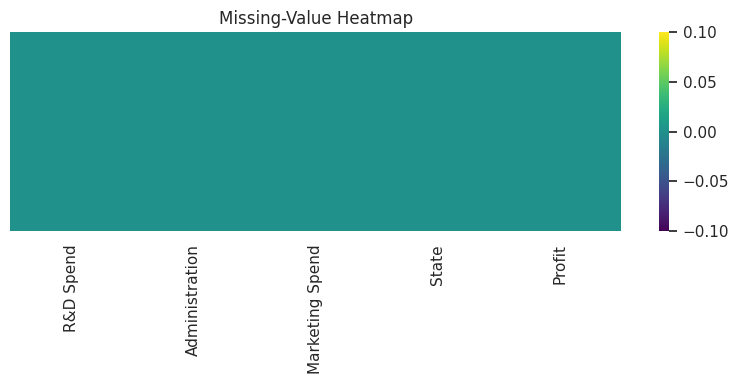

In [12]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing-Value Heatmap')
plt.tight_layout()
plt.show()

---
## 6 · Duplicate Check

Identify and count exact duplicate rows.

In [13]:
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count}')

if dup_count > 0:
    print('\nDuplicate rows:')
    display(df[df.duplicated(keep=False)])

Duplicate rows: 0


---
## 7 · Descriptive Statistics

### 7.1 — Numerical Summary

In [14]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


### 7.2 — Categorical Summary

In [15]:
df.describe(include='object')

/tmp/ipykernel_70051/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,State
count,50
unique,3
top,Pakistan
freq,17


---
## 8 · Target Distribution

Visualize the distribution of the target variable — **Profit**.

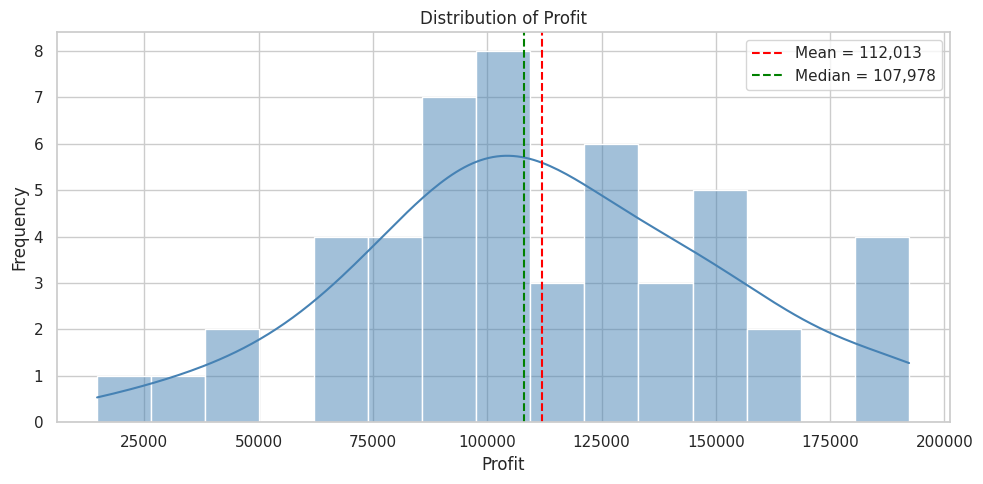

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Profit'], kde=True, bins=15, color='steelblue')
plt.axvline(df['Profit'].mean(), color='red', linestyle='--', label=f"Mean = {df['Profit'].mean():,.0f}")
plt.axvline(df['Profit'].median(), color='green', linestyle='--', label=f"Median = {df['Profit'].median():,.0f}")
plt.title('Distribution of Profit')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

---
## 9 · Feature Distributions

### 9.1 — Histograms of all numeric features

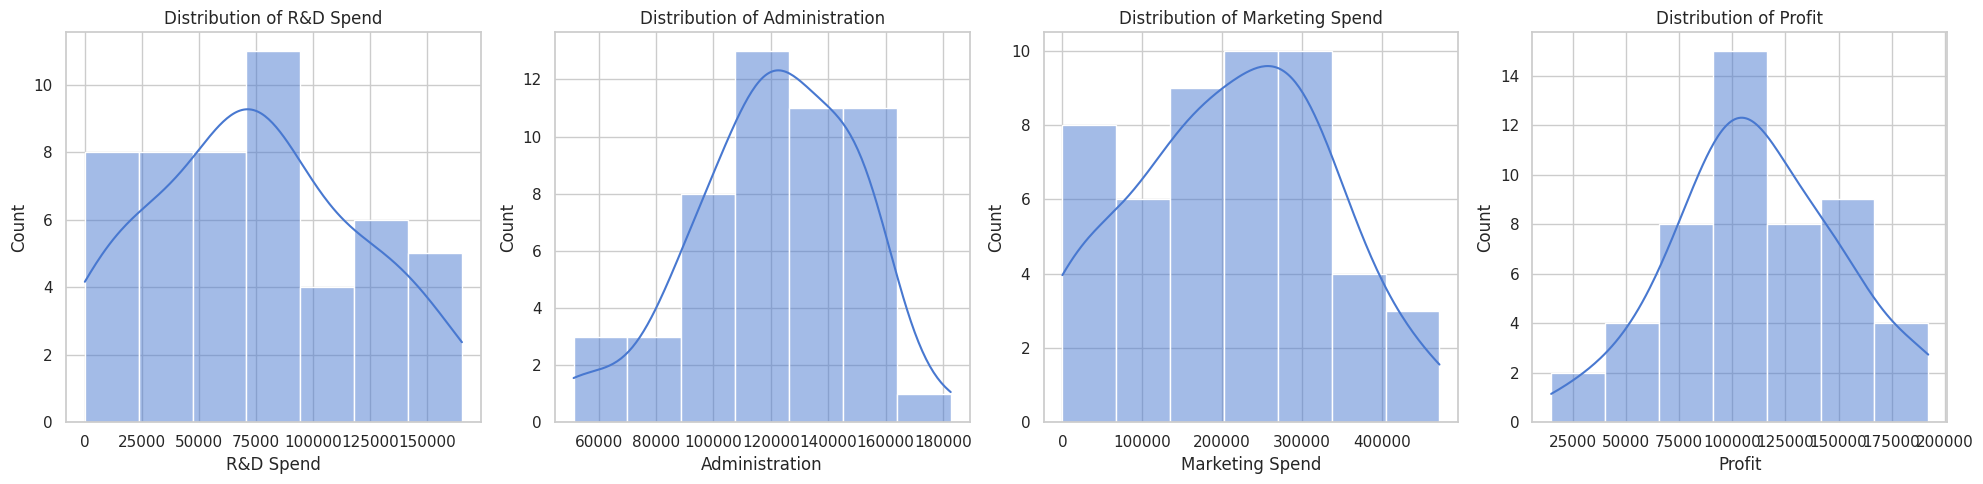

In [17]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 5))

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

### 9.2 — Box Plots (outlier detection)

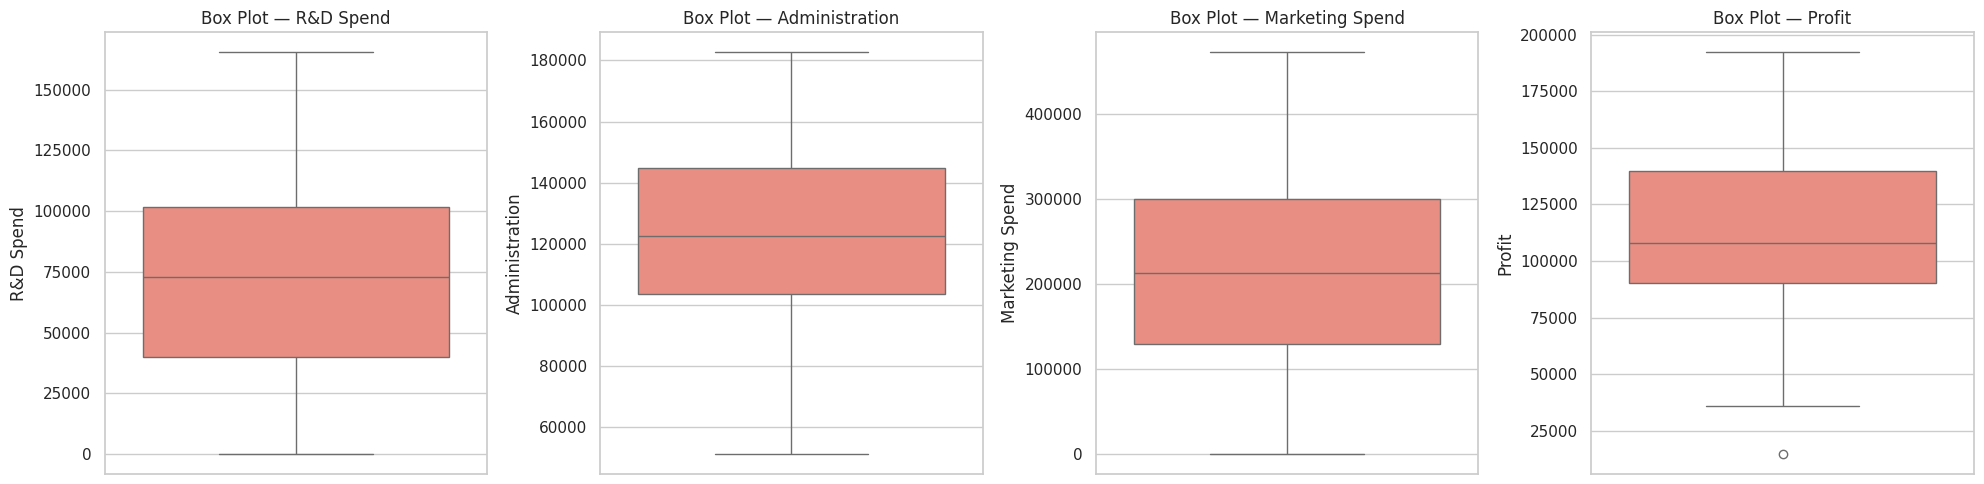

In [18]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5 * len(numeric_cols), 5))

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color='salmon')
    ax.set_title(f'Box Plot — {col}')

plt.tight_layout()
plt.show()

---
## 10 · Scatter Plots — Features vs Target

Examine the linear relationship between each numeric feature and Profit.

### 10.1 — R&D Spend vs Profit

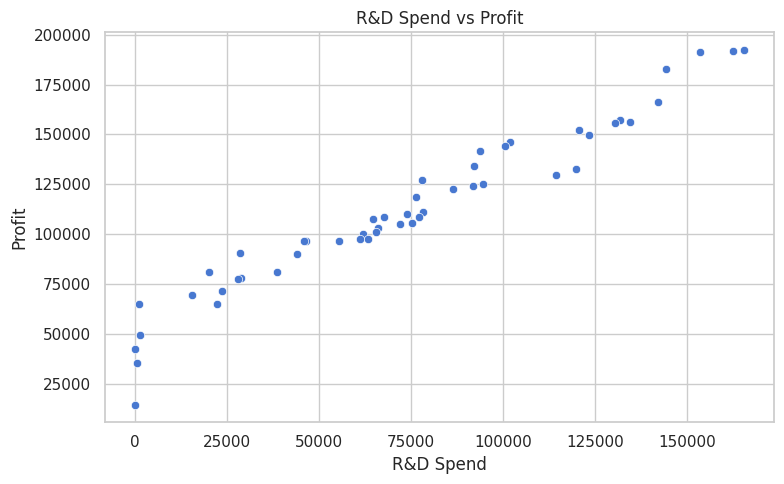

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='R&D Spend', y='Profit', data=df)
plt.title('R&D Spend vs Profit')
plt.tight_layout()
plt.show()

### 10.2 — Administration vs Profit

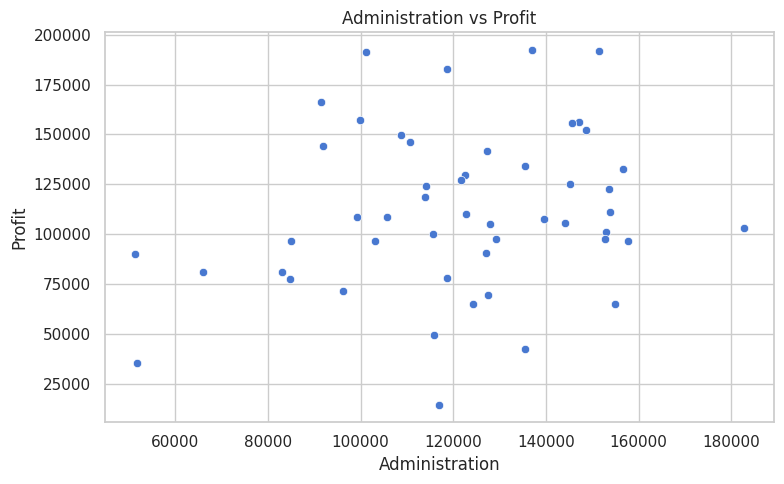

In [20]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Administration', y='Profit', data=df)
plt.title('Administration vs Profit')
plt.tight_layout()
plt.show()

### 10.3 — Marketing Spend vs Profit

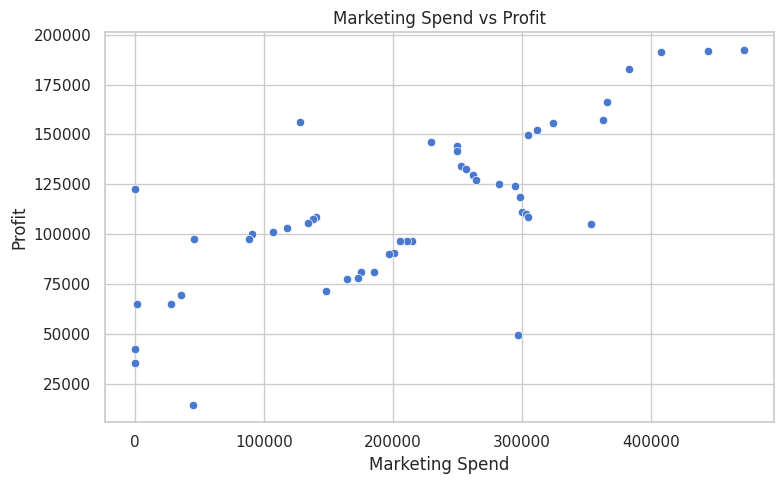

In [21]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Marketing Spend', y='Profit', data=df)
plt.title('Marketing Spend vs Profit')
plt.tight_layout()
plt.show()

---
## 11 · Categorical Analysis

### 11.1 — State Value Counts

In [22]:
df['State'].value_counts()

State
Pakistan      17
California    17
Istanbul      16
Name: count, dtype: int64

### 11.2 — State Count Plot

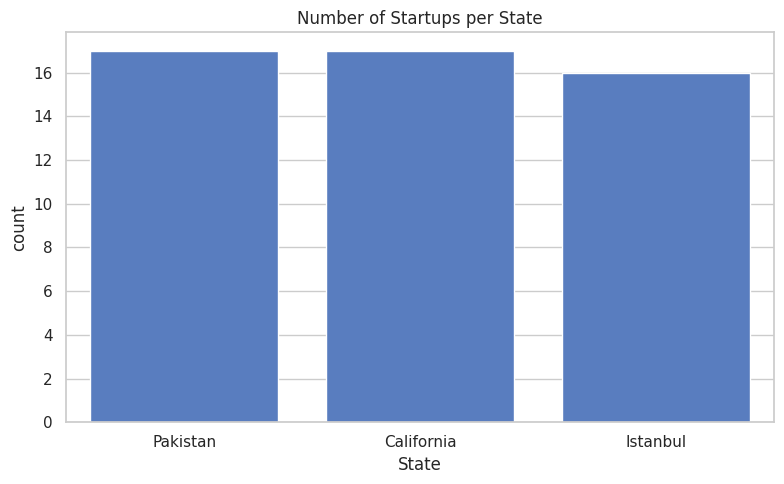

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(x='State', data=df, order=df['State'].value_counts().index)
plt.title('Number of Startups per State')
plt.tight_layout()
plt.show()

### 11.3 — Profit by State (Box Plot)

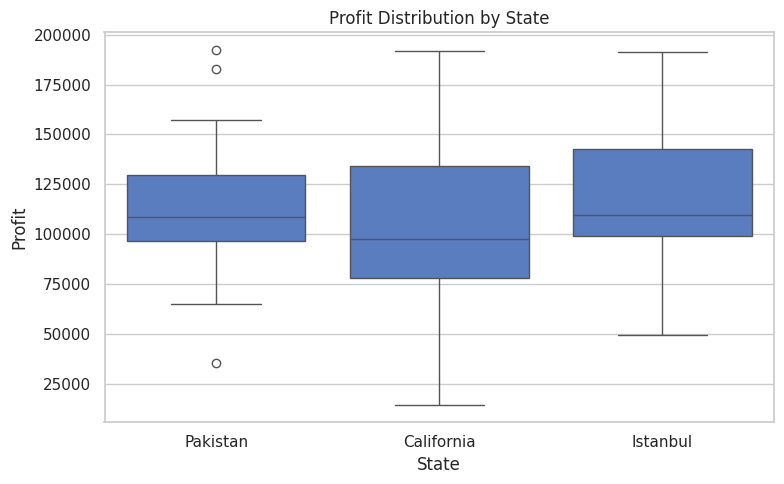

In [24]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='State', y='Profit', data=df)
plt.title('Profit Distribution by State')
plt.tight_layout()
plt.show()

---
## 12 · Correlation Matrix

Examine pairwise correlations among numeric features.

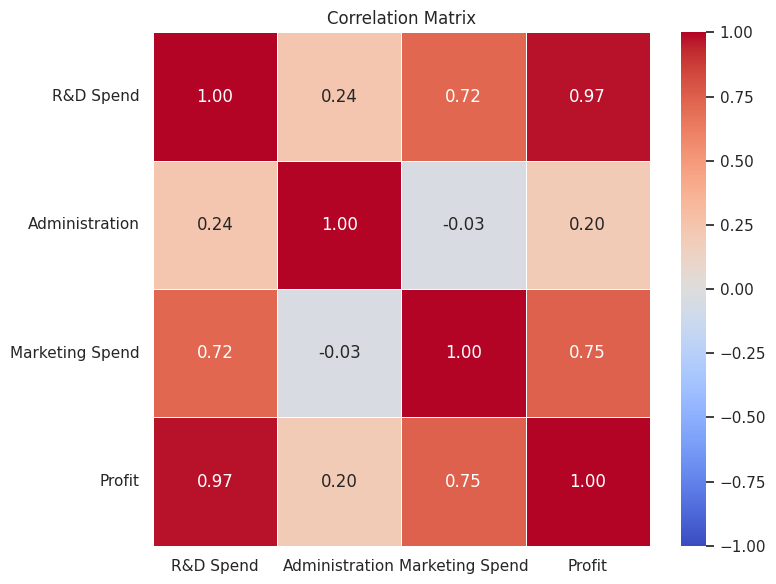

In [25]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### 12.1 — Correlation with Target

In [26]:
corr['Profit'].drop('Profit').sort_values(ascending=False)

R&D Spend          0.972900
Marketing Spend    0.747766
Administration     0.200717
Name: Profit, dtype: float64

---
## 13 · Pairplot

Scatter matrix of all numeric variables, colored by State.

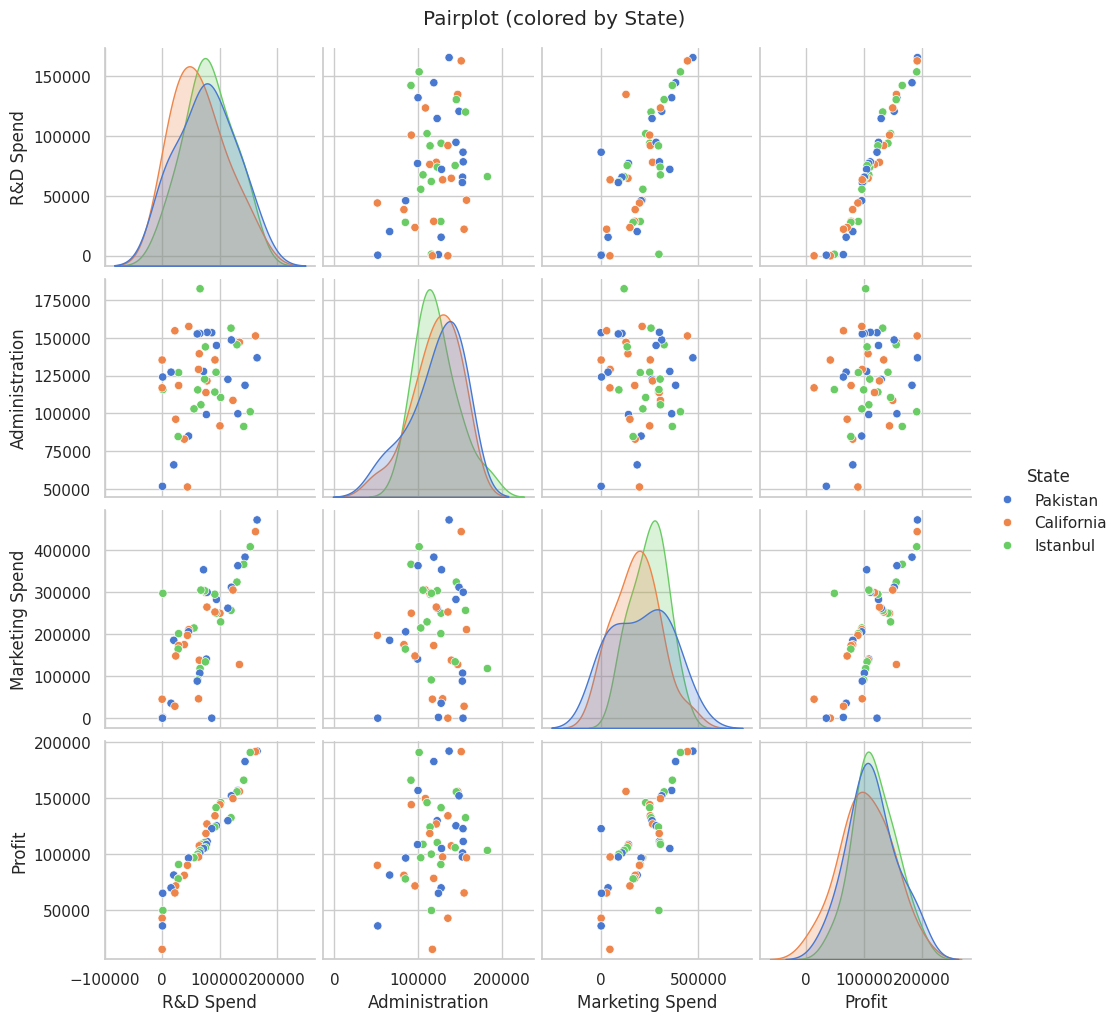

In [27]:
sns.pairplot(df, hue='State', diag_kind='kde')
plt.suptitle('Pairplot (colored by State)', y=1.02)
plt.show()

---
## 14 · One-Hot Encoding

Convert the categorical **State** column into dummy variables.

In [28]:
df_encoded = pd.get_dummies(df, columns=['State'], drop_first=True)
print(f'Columns after encoding: {df_encoded.columns.tolist()}')
df_encoded.head()

Columns after encoding: ['R&D Spend', 'Administration', 'Marketing Spend', 'Profit', 'State_Istanbul', 'State_Pakistan']


,R&D Spend,Administration,Marketing Spend,Profit,State_Istanbul,State_Pakistan
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


---
## 15 · Feature–Target Split

Separate independent variables (**X**) from the target variable (**y**).

In [29]:
X = df_encoded.drop('Profit', axis=1)
y = df_encoded['Profit']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (50, 5)
y shape: (50,)


---
## 16 · Train–Test Split

80 / 20 split with a fixed random state for reproducibility.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}  |  y_test: {y_test.shape}')

X_train: (40, 5)  |  X_test: (10, 5)
y_train: (40,)  |  y_test: (10,)


---
## 17 · Model Training

Fit a **Multiple Linear Regression** model on the training set.

In [31]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')
print(f'Intercept: {model.intercept_:,.2f}')

Model trained successfully.
Intercept: 54,028.04


---
## 18 · Predictions

Generate predictions on the test set and compare with actuals.

In [32]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({'Actual': y_test.values, 'Predicted': y_pred})
comparison['Error'] = comparison['Actual'] - comparison['Predicted']
comparison

,Actual,Predicted,Error
0,134307.35,126362.879083,7944.470917
1,81005.76,84608.453836,-3602.693836
2,99937.59,99677.494251,260.095749
3,64926.08,46357.460686,18568.619314
4,125370.37,128750.482885,-3380.112885
5,35673.41,50912.417419,-15239.007419
6,105733.54,109741.350327,-4007.810327
7,107404.34,100643.242816,6761.097184
8,97427.84,97599.275746,-171.435746
9,122776.86,113097.425244,9679.434756


---
## 19 · Evaluation Metrics

Quantify model performance using standard regression metrics.

In [33]:
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'R² Score                    : {r2:.4f}')
print(f'Mean Absolute Error  (MAE)  : {mae:,.2f}')
print(f'Mean Squared Error   (MSE)  : {mse:,.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:,.2f}')

R² Score                    : 0.8987
Mean Absolute Error  (MAE)  : 6,961.48
Mean Squared Error   (MSE)  : 82,010,363.04
Root Mean Squared Error (RMSE): 9,055.96


---
## 20 · Actual vs Predicted Plot

Points closer to the red dashed line indicate better predictions.

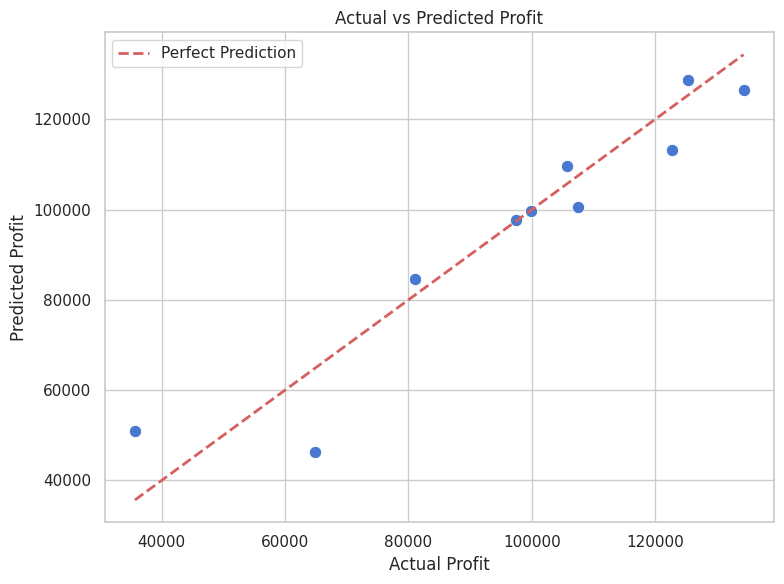

In [34]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, s=80)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    '--r', linewidth=2, label='Perfect Prediction'
)
plt.xlabel('Actual Profit')
plt.ylabel('Predicted Profit')
plt.title('Actual vs Predicted Profit')
plt.legend()
plt.tight_layout()
plt.show()

---
## 21 · Residual Analysis

Residuals should be randomly scattered around zero for a well-fitted model.

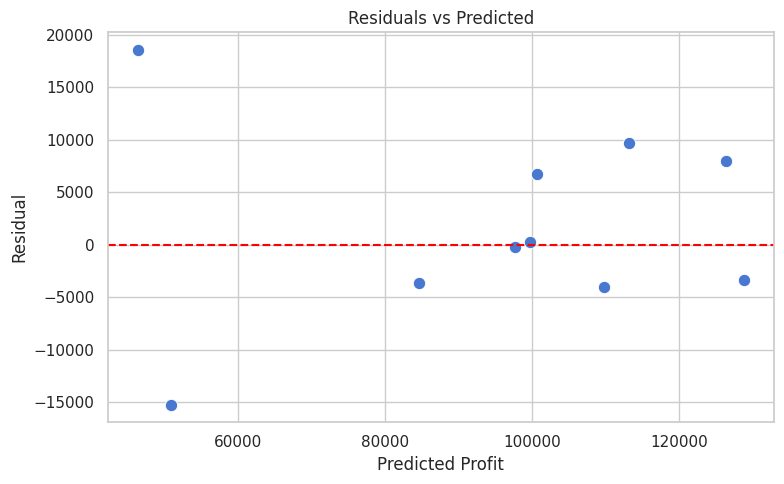

In [35]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals, s=80)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Profit')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted')
plt.tight_layout()
plt.show()

### 21.1 — Residual Distribution

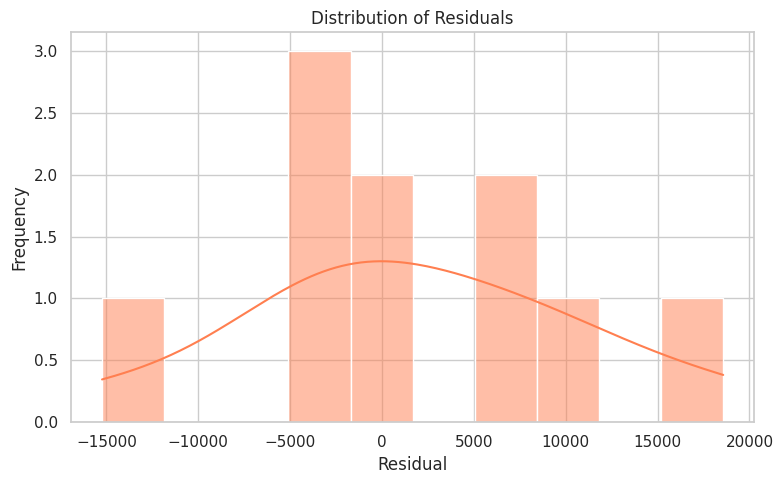

In [36]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=10, color='coral')
plt.title('Distribution of Residuals')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

---
## 22 · Feature Importance

Model coefficients indicate how much each feature influences profit (holding others constant).

In [37]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

coef_df

,Feature,Coefficient
3,State_Istanbul,938.793006
4,State_Pakistan,6.987760
0,R&D Spend,0.805630
2,Marketing Spend,0.029855
1,Administration,-0.068788


### 22.1 — Coefficient Bar Chart

/tmp/ipykernel_70051/1288200969.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')


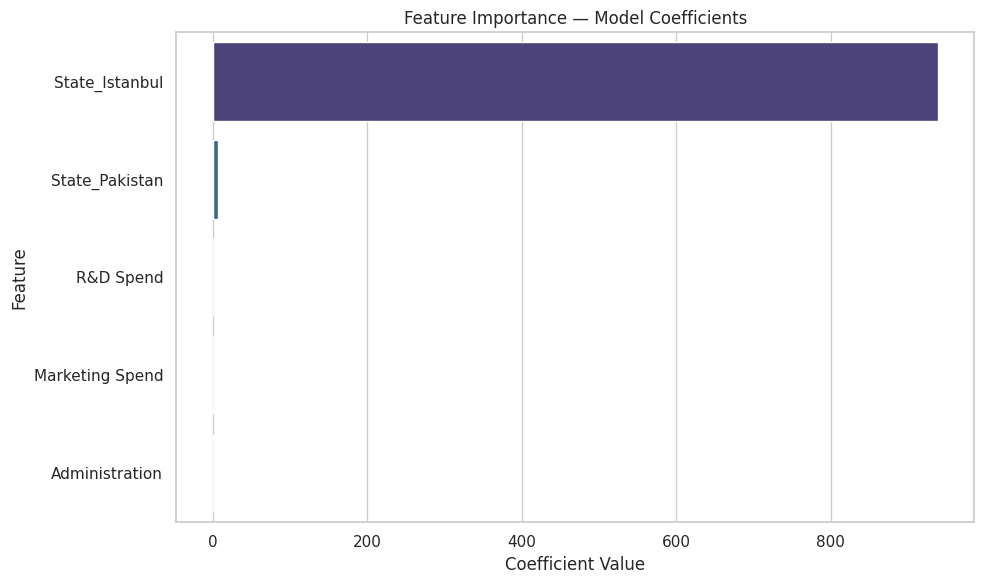

In [38]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Feature Importance — Model Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

---
## 23 · Conclusion

| Insight | Detail |
|---------|--------|
| **Model Performance** | The R² score quantifies how well our features explain Profit variance. MAE / RMSE give the average prediction error in dollar terms. |
| **Key Driver** | R&D Spend shows the strongest positive correlation and largest coefficient — it is the most important predictor of Profit. |
| **Administration** | Has a weaker (and potentially negative) relationship with Profit, suggesting over-spending on administration may not help. |
| **Marketing Spend** | Moderate positive influence; useful but secondary to R&D. |
| **State** | Minimal impact on Profit after encoding — geographic location is not a strong predictor. |

**Recommendation**: A venture capital firm should prioritize startups that invest heavily in R&D, followed by Marketing — while keeping Administration costs lean.